# Simulación de un robot planar de 2 GDL

Modelo dinámico del robot manipulador planar de dos grados de libertad.

\[
M(q)\ddot{q} + C(q,\dot{q})\dot{q} + g(q) + f(\dot{q}) = \tau
\]

\[
\ddot{q} = M(q)^{-1}\left[\tau - C(q,\dot{q})\dot{q} - g(q) - f(\dot{q})\right]
\]

Tiempo total de simulación: **10 segundos**.


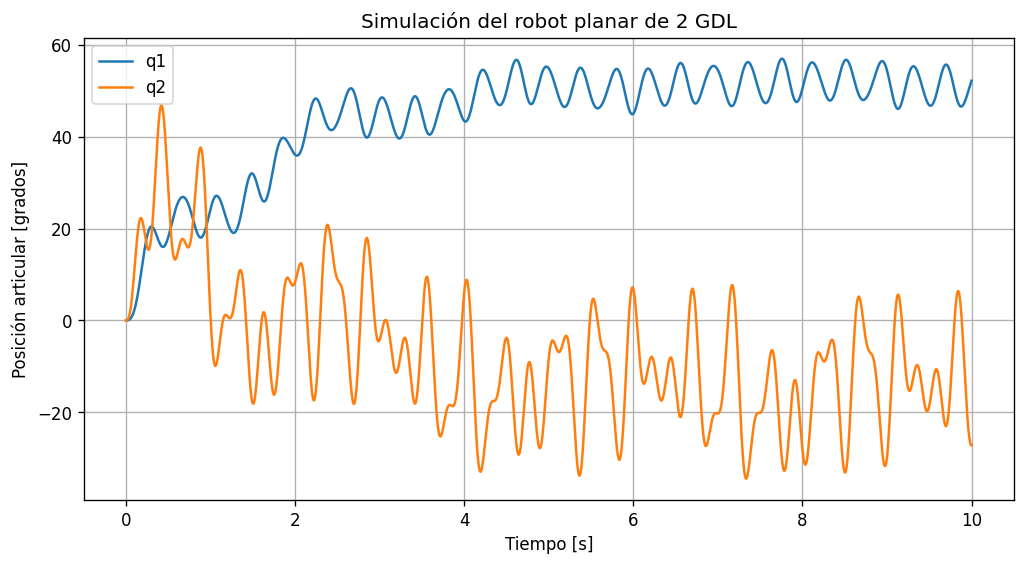

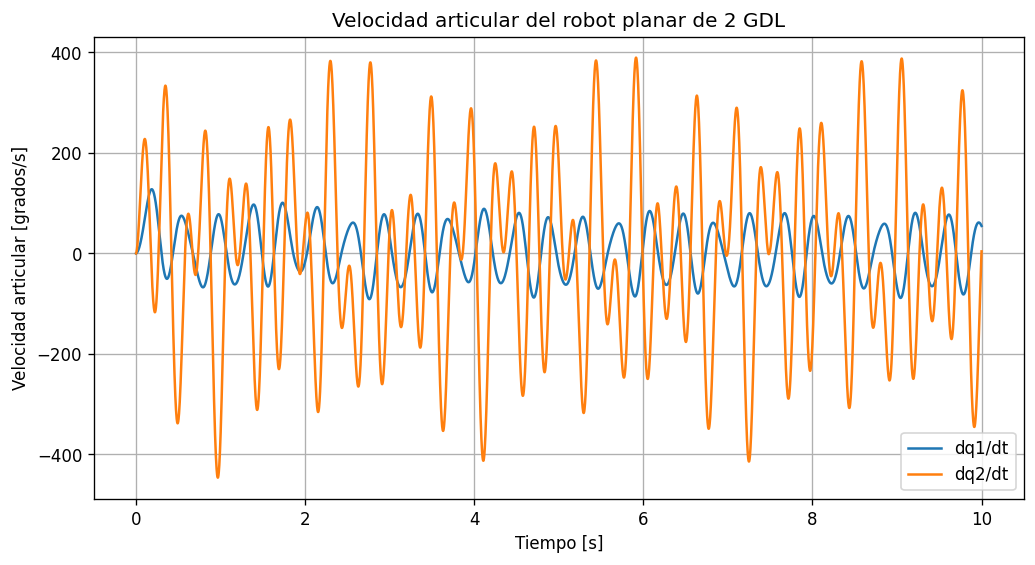

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def robot_2gdl(t, x):
    q1 = x[0]
    q2 = x[1]
    qp1 = x[2]
    qp2 = x[3]

    qp = np.array([qp1, qp2])

    M = np.array([
        [3.117 + 0.2*np.cos(q2), 0.108 + 0.1*np.cos(q2)],
        [0.108 + 0.1*np.cos(q2), 0.108]
    ])

    C = np.array([
        [-0.2*np.sin(q2)*qp2, -0.1*np.sin(q2)*qp2],
        [0.1*np.sin(q2)*qp1, 0]
    ])

    g = np.array([
        39.3*np.sin(q1) + 1.95*np.sin(q1 + q2),
        1.95*np.sin(q1 + q2)
    ])

    f = np.array([
        1.86*qp1 + 1.93*np.sign(qp1),
        0.16*qp2 + 0.3*np.sign(qp2)
    ])

    tau = np.array([
        (1 - np.exp(-0.8*t))*32.0 + 56*np.sin(16*t + 0.1) + 12*np.sin(20*t + 0.15),
        (1 - np.exp(-1.8*t))*1.2 + 8*np.sin(26*t + 0.08) + 2*np.sin(12*t + 0.34)
    ])

    qpp = np.linalg.solve(M, tau - C @ qp - g - f)

    return [qp1, qp2, qpp[0], qpp[1]]


ti = 0
h = 0.002
tf = 10
t_eval = np.linspace(ti, tf, int((tf - ti) / h) + 1)

x0 = [0, 0, 0, 0]

sol = solve_ivp(
    robot_2gdl,
    [ti, tf],
    x0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-3,
    atol=1e-6
)

q1_deg = np.rad2deg(sol.y[0])
q2_deg = np.rad2deg(sol.y[1])
qp1_deg = np.rad2deg(sol.y[2])
qp2_deg = np.rad2deg(sol.y[3])

plt.figure(figsize=(10, 5))
plt.plot(sol.t, q1_deg, label='q1')
plt.plot(sol.t, q2_deg, label='q2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición articular [grados]')
plt.title('Simulación del robot planar de 2 GDL')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sol.t, qp1_deg, label='dq1/dt')
plt.plot(sol.t, qp2_deg, label='dq2/dt')
plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad articular [grados/s]')
plt.title('Velocidad articular del robot planar de 2 GDL')
plt.grid(True)
plt.legend()
plt.show()
